# Tutorial: Identifying genes under selection with AccuSNV
## **Parallel mutations and dN/dS**

### Load data and run AccuSNV

When running AccuSNV, you first need to gather the key input files you'll need:
1. FASTQ files
2. Your sample sheet
3. Your reference genome and annotations.

For this tutorial, we are working with the lineage L01 data from the [Zhao and Lieberman 2019 paper](https://www.cell.com/cell-host-microbe/fulltext/S1931-3128(19)30159-3), "Adaptive Evolution within Gut Microbiomes of Healthy People".

This is just a subset of the data in the paper, but it is a lineage in which significant parallel evolution was observed.

The FASTQ samples can be found at https://www.ncbi.nlm.nih.gov/bioproject/PRJNA524913/.

The reference genome and annotation we use can be downloaded from NCBI [here](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_000025985.1/). Download FASTA and gff.

The sample sheet, for reference, can be found hosted on GitHub in this same directory.

Finally, because you likely do not want to run AccuSNV yourself on a medium-sized dataset like this, we have made the AccuSNV outputs used in this tutorial available here on GitHub, so you just need to clone this repository to run this notebook tutorial.  

### Running AccuSNV

Before this tutorial, AccuSNV was run with the following command on the data described above:

```
accusnv -i zhaolieberman_data.csv -j 16 -r reference_genome/ -o accusnv_bfragilis_L01 --mode slurm
```

### Looking at the results

We can import our AccuSNV results from the run found in this directory on GitHub.

The Final SNV table contains almost all of the information we will need, and that would be needed for most analyses. 

You can read it in with pandas:

In [1]:
import pandas as pd

snvs = pd.read_csv('./group_L01_snv_table_final.tsv', sep="\t")

Let's look at the number of different mutation types:

Remember S= synonymous, N=non-synonymous, I=intergenic, and P=promoter (upstream of a gene).

In [2]:
print("{} total SNVs".format(snvs.shape[0]))
snvs.mutation_type.value_counts()

490 total SNVs


mutation_type
S    339
N    123
I     17
P     11
Name: count, dtype: int64

That's a lot of SNVs! Let's look at how many unique genes they are found in:

In [3]:
snvs.protein_id.nunique()

85

### Inspect potential recombinant sites

So, we have 400+ SNVs. But the original paper finds <100 SNVs in this lineage. What could explain this difference?

The paper identified a prophage region (MED01-2+) in some genomes from this lineage. If the prophage carries SNVs, then
those SNVs would be clustered together, and not indicative of the clonal ancestry of these isolates, and therefore should be removed. 

AccuSNV identifies regions like this with the recombinant block detection. 

Let's plot the location of our SNVs across the genome, plotting sites flagged as recombinant blocks in **red**:

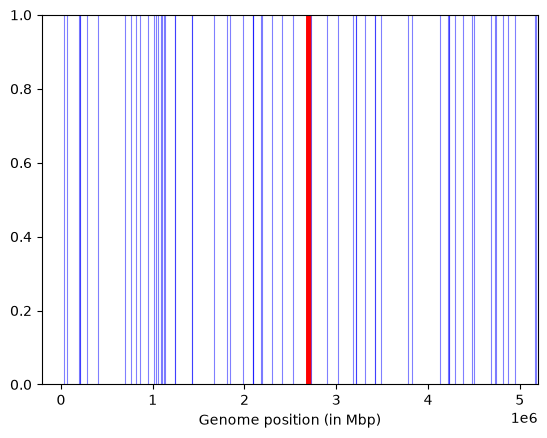

In [4]:
import matplotlib.pyplot as plt

for site in snvs.query("Whether_recomb == 1")["contig_pos"]: #recombinant snvs
    plt.axvline(site, color="red", alpha=0.5, linewidth=0.1)

for site in snvs.query("Whether_recomb == 0")["contig_pos"]: # nonrecombinant snvs
    plt.axvline(site, color="blue", alpha=0.5, linewidth=0.8)

plt.xlabel("Genome position (in Mbp)")
plt.show()

We can see that indeed there is a very large cluster of recombinant SNVs all in the same region! This is indeed the prophage region of the genome. Therefore, these SNVs can be removed from future analysis:

In [5]:
print("{} total SNVs before filtering recombinant blocks".format(snvs.shape[0]))
snvs = snvs.query("Whether_recomb == 0")
print("{} total SNVs after filtering recombinant blocks".format(snvs.shape[0]))


490 total SNVs before filtering recombinant blocks
63 total SNVs after filtering recombinant blocks


And we end up with 63 clonal SNVs. This is just slightly fewer than the number reported in the original paper, likely because of more stringent AccuSNV filtering.

### Identifying genes undergoing parallel evolution

Next, let's test to see if there are any genes that have acquired multiple independent mutations, and therefore may be undergoing parallel evolution.

Filter to genes that have at least 2 independent mutations:

In [28]:
snvs = snvs[snvs.mutation_type.isin(["N", "S"])]
parallel_genes = snvs.protein_id.value_counts()[snvs.protein_id.value_counts() >= 2]
parallel_genes

protein_id
WP_010992678.1    3
WP_005798155.1    3
WP_005783855.1    2
WP_005785453.1    2
WP_005785776.1    2
WP_005788914.1    2
Name: count, dtype: int64

So there are 6 genes potentially undergoing parallel evolution, and 2 genes with **3** SNVs.

In this tutorial we're using NCBI protein accessions, and for reference, here is how they correspond to the gene names mentioned in the original paper:

| Locus tag | Protein ID | Mutation count | Product |
|---|---|---:|---|
| BF1802 | WP_010992678 | 3 | SusD |
| BF3581 | WP_005798155 | 3 | SusC |
| BF2942 | WP_005788914 | 2 | SusC |
| BF0188 | WP_005783855 | 2 | LPS transporter |
| BF0991 | WP_005785453 | 2 | Tetratricopeptide repeat protein |
| BF1174 | WP_005785776 | 2 | Transcriptional regulator |

The two genes with **3** independent mutations in them were SusD and SusC homologs.

However, is this degree of parallel evolution significant? Is it more than what you might expect by chance distribution of this many SNVs across the genome?

Next, we test for that with a permutation test.

#### Read in gene information
Here we read the GFF to get the size of each gene, to weight its odds of receiving a mutation exactly.

In [8]:
genes = pd.read_csv('./reference_genome/GCF_000025985.1.gff', sep="\t", comment="#", header=None).query("`2` == 'CDS'")
genes['gene_id'] = genes[8].str.split(";", expand=True)[0].str.split("-", expand=True)[1]
genes['gene_length'] = genes[4] - genes[3]
genes['gene_probabilities'] = genes['gene_length'] / genes['gene_length'].sum()

#### Perform a permutation test

Randomly permute the number of observed snvs across the number of genes in the genome, weighted by their gene lengths as a fraction of all coding length.

In [9]:
import numpy as np

permutations = 100000 # 100,000 iterations

parallel_gene_null_results = [] # Collect number of parallel genes (>1 mutation)
parallel_gene_null_results_3snvs = [] # Collect number of parallel genes (>2 mutations)

for n in range(0, permutations):

    random_genes = np.random.choice(
        a=genes.gene_id, # for all genes in the genome
        size=snvs.shape[0], # assign the number of observed SNVs
        p=genes.gene_probabilities # weight each gene by its length
    )

    random_gene_counts = pd.Series(random_genes).value_counts()
    num_parallel = random_gene_counts[random_gene_counts > 1].shape[0] # number of parallel genes in this iteration
    parallel_gene_null_results.append(num_parallel) 

    num_parallel3 = random_gene_counts[random_gene_counts > 2].shape[0] # number of parallel genes in this iteration
    parallel_gene_null_results_3snvs.append(num_parallel3)

parallel_gene_nulls = pd.Series(parallel_gene_null_results).value_counts(normalize=True)
parallel_gene_null_results_3snvs = pd.Series(parallel_gene_null_results_3snvs).value_counts(normalize=True)

Visualize the resulting distribution of the number of parallel genes observed in each iteration:

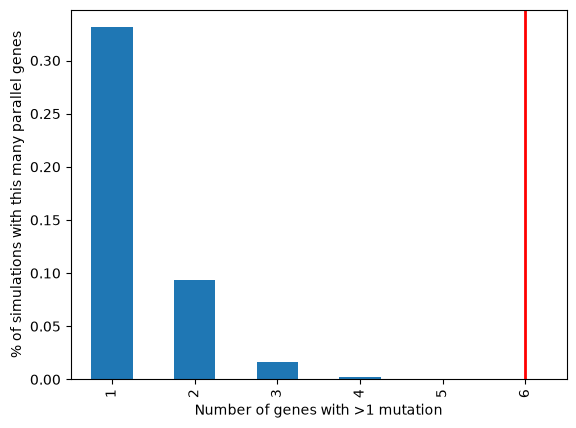

In [ ]:
ax = parallel_gene_nulls[parallel_gene_nulls.index > 0].plot.bar()
plt.xlabel("Number of genes with >1 mutation")
plt.ylabel("% of simulations with this many parallel genes")

# Plot the observed number of parallel genes
ax.axvline(x=list(parallel_gene_nulls[parallel_gene_nulls.index > 0].index).index(6), color="red", linewidth=2)

plt.show()

In [29]:
print("number of genes with 2 or more SNVs per simulation")
print(parallel_gene_nulls)

print("number of genes with 3 or more SNVs per simulation")
print(parallel_gene_null_results_3snvs)


number of genes with 2 or more SNVs per simulation
0    0.55630
1    0.33119
2    0.09360
3    0.01658
4    0.00210
5    0.00022
6    0.00001
Name: proportion, dtype: float64
number of genes with 3 or more SNVs per simulation
0    0.99479
1    0.00521
Name: proportion, dtype: float64


In each case, we have observed more genes mutated in parallel than would be expected by chance:

We observe **6 genes with 2 or more SNVs, which is found in 1 in 100,000 simulations**

We observe **2 genes with 3 or more SNVs, which is found <1 in 100,000 simulations.**

#### Assigning p-values to genes undergoing parallel evolution

We can go further than the 2019 paper and assign an FDR-corrected p-value for each gene, assuming a null poisson distribution of mutations in genes across the genome.

In [32]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

# expected hits per gene under neutrality
lam = snvs.shape[0] * genes.gene_probabilities          # mutation_rate * genes.gene_length

# upper-tail p-value: P(X >= observed)
genes['pval'] = stats.poisson.sf(genes.gene_id.map(pd.Series(snvs.protein_id).value_counts()).fillna(0) - 1, lam)

# Benjamini-Hochberg FDR
genes['qval'] = multipletests(genes.pval, method='fdr_bh')[1]

parallel_genes_pvals = genes[genes.qval < 1].sort_values('qval')
parallel_genes_pvals[['gene_id', 'pval', 'qval']]

,gene_id,pval,qval
3397,WP_010992678.1,0.000001,0.005977
7031,WP_005798155.1,0.000014,0.028627
2215,WP_005785776.1,0.000064,0.090361
1897,WP_005785453.1,0.000140,0.147668
351,WP_005783855.1,0.000267,0.225604
5743,WP_005788914.1,0.000891,0.628507


With this statistical test, `WP_010992678.1` and `WP_005798155.1`, (*susD* and *susC*) have statistically significant FDR corrected p-values.

### Calculate *dN/dS* of genes undergoing parallel evolution

Now we can ask if the genes identified above have an enrichment in non-synonymous mutations compared to synonymous mutations, after normalizing for expected rates, [a classic signature of selection](https://en.wikipedia.org/wiki/Ka/Ks_ratio). It is easy to recalculate *dN/dS* with accusnv for just the genes above:

In [30]:
import numpy as np
from accusnv.downstream import dnds, snv
from accusnv.preprocessing.utils import ref_directory, genomestats

## Calculate observed mutational spectral across the entire genome
mut_observed = dnds.mutation_spectrum_module(snvs, np.array(['A','T','C','G','N']))[1]
mut_spec_prob = mut_observed / mut_observed.sum() if mut_observed.sum() >= 100 else np.ones(6) / 6

## Get all genes
all_genes = pd.concat(snv.parse_gff('./reference_genome/', genomestats('./reference_genome/')[2])).reset_index()

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from accusnv.downstream import dnds, snv
from accusnv.preprocessing.utils import genomestats

## Get the parallel genes, and all other genes with mutations
gene_nums = snvs[snvs.protein_id.isin(parallel_genes.index)]['gene_num_global'].unique()
other_gene_nums = snvs[~snvs.protein_id.isin(parallel_genes.index)]['gene_num_global'].unique()

## Compute dN/dS for parallel genes vs other mutated genes
p_exp_other = dnds.compute_expected_dnds(all_genes, mut_spec_prob)
p_exp_par = dnds.compute_expected_dnds(all_genes, mut_spec_prob, gene_nums)

## Estimate dN/dS confidence intervals
odds = lambda p: p/(1-p) if p < 1 else np.inf
def dnds_ci(snvs, genes, p_exp):
    p, ci, n, s = dnds.compute_observed_dnds(snvs, genes)
    est = odds(p)/odds(p_exp)
    lo, hi = odds(ci[0])/odds(p_exp), odds(ci[1])/odds(p_exp)
    return est, lo, hi, n, s

## Estimates for parallel genes
est_all, lo_all, hi_all, n_other, s_other = dnds_ci(snvs, other_gene_nums, p_exp_other)

## Estimates for other genes
est_par, lo_par, hi_par, n_par, s_par = dnds_ci(snvs, gene_nums, p_exp_par)

## Values for plotting
est = [est_all, est_par]
err_lo = [est_all - lo_all, est_par - lo_par]
err_hi = [hi_all - est_all, hi_par - est_par]


print(f'Genes mutated in parallel: (N={n_par},S={s_par})')
print("Genes mutated in parallel dN/dS: {}".format(est_par))

print(f'Other genes with mutations:  (N={n_other},S={s_other})')
print("Other genes with mutations dN/dS: {}".format(est_all))

Genes mutated in parallel: (N=12,S=2)
Genes mutated in parallel dN/dS: 1.6523719365170317
Other genes with mutations:  (N=28,S=17)
Other genes with mutations dN/dS: 0.47289135470965327


Genes that were mutated in parallel had **12** Non-synonymous mutations, while only **2** synonymous; while other genes had **28** N mutations and **17** S. 

We can next visualize their differences in *dN/dS* ratios with confidence intervals:

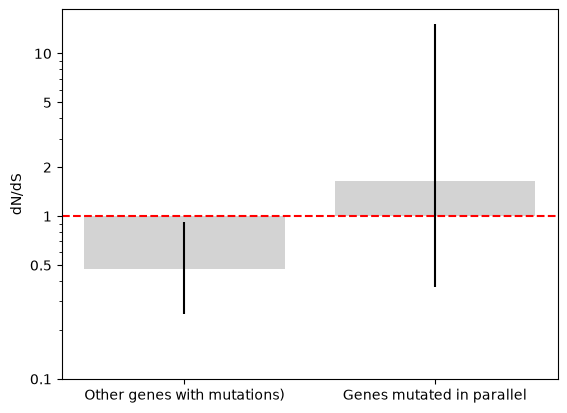

In [50]:
plt.bar([f'Other genes with mutations)', f'Genes mutated in parallel'], [x-1 for x in est], yerr=[err_lo, err_hi], capsize=0, color='lightgrey', bottom=1)

plt.axhline(1, linestyle='--', color='red')
plt.ylabel('dN/dS')
plt.yscale("log")
plt.yticks([0.1, 0.5, 1, 2, 5, 10], [0.1, 0.5, 1, 2, 5, 10])

plt.show()

This comparison is a bit under-powered compared to the original paper, because we're just looking at genes from one lineage. 

But despite this, we can then test that these two distributions are indeed different using a Fisher's exact test:

In [27]:
from scipy import stats

pvalue = (round(stats.fisher_exact([[n_par, s_par],
                    [n_other - n_par, s_other - s_par]],
                   alternative='greater').pvalue, 3))

print("Fisher's Exact test p-value: {}".format(pvalue))

Fisher's Exact test p-value: 1.0


### Visualize mutations on the tree

Finally, you may wish to visualize where mutations in these genes undergoing positive selection occur on the tree. Let's use the `tree_annotated_plot` library in Python to visualize the distribution of SNVs on the tree. (First, run `pip install altair tree-annotated-plot`). Let's make a facet for each gene, with circles to signify the presence of a non-synonymous SNV in that gene:


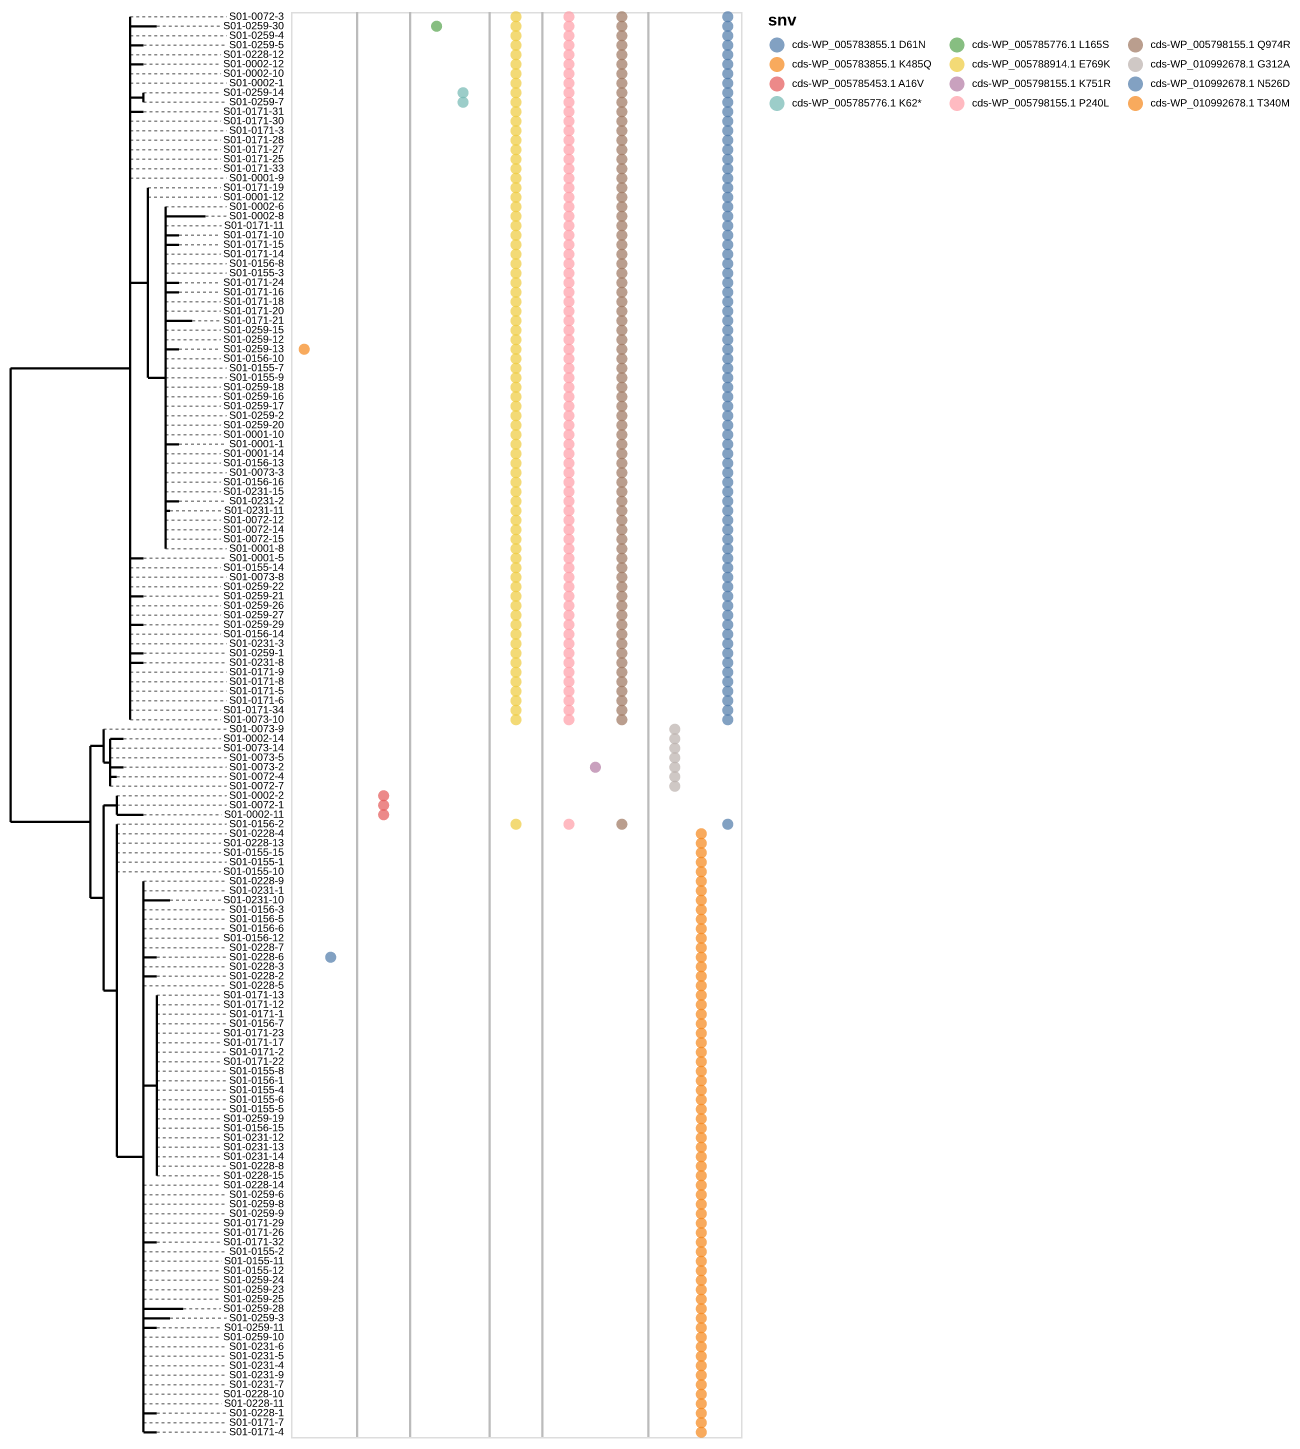

In [101]:
import altair as alt
import pandas as pd
from Bio import Phylo
import tree_annotated_plot as tap

counts = snvs[snvs.mutation_type.isin(['N','S'])].protein_id.value_counts()
muts = snvs[snvs.protein_id.isin(counts[counts >= 2].index) & (snvs.mutation_type == 'N')]
muts = muts.sort_values(['protein_id', 'aa_pos'])

samples = [c for c in snvs.columns if c.startswith('S')]
data = pd.DataFrame([(s, f"{r.locus_tag} {r.aa_mutation}")
                     for _, r in muts.iterrows() for s in samples if r[s] == r.derived_allele],
                    columns=['strain', 'snv'])

tree = Phylo.read('./group_L01_snv_tree_final.nwk.tree', 'newick')

depths = tree.depths()
def aus(cl):
    node = {"name": cl.name or "", "node_attrs": {"div": float(depths[cl])}}
    if cl.clades:
        node["children"] = [aus(c) for c in cl.clades]
    return node
auspice = {"version": "v2", "tree": aus(tree.root)}

genes = list(dict.fromkeys(r.locus_tag for _, r in muts.iterrows()))
lab_of = {}
for _, r in muts.iterrows():
    lab_of.setdefault(r.locus_tag, []).append(f"{r.locus_tag} {r.aa_mutation}")
spacers = [f"gap{i}" for i in range(len(genes) - 1)]
order, si = [], 0
for i, g in enumerate(genes):
    order += lab_of[g]
    if i < len(genes) - 1:
        order.append(spacers[si]); si += 1

circles = alt.Chart(data, height=5 * tree.count_terminals(), width=300).mark_circle(size=55).encode(
    x=alt.X('snv:N', sort=order, axis=None),
    y=alt.Y('strain:N'),
    color=alt.Color('snv:N', legend=alt.Legend(columns=3, labelFontSize=7)))
rules = alt.Chart(pd.DataFrame({'snv': spacers})).mark_rule(color='#bbb', strokeWidth=1.5).encode(
    x=alt.X('snv:N', sort=order))
chart = alt.layer(circles, rules).resolve_scale(x='shared')

fig = tap.plot(auspice, chart, chart_strain_field='strain', tree_strain_field='name',
               branch_length='div', tree_size=130, prune_tree_to_chart=True,
               connect_leader_to_label=True, strain_label_font_size=7,
               tree_line_width=1.5, tree_node_size=0)

from IPython.display import Image

fig.save('./tree_snvs.png', scale_factor=1.5)   # rendered by vl-convert (installed as a dep)
Image('./tree_snvs.png')